In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
train = pd.read_csv("titanic_train.csv")
test = pd.read_csv("titanic_test.csv")

In [179]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [180]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

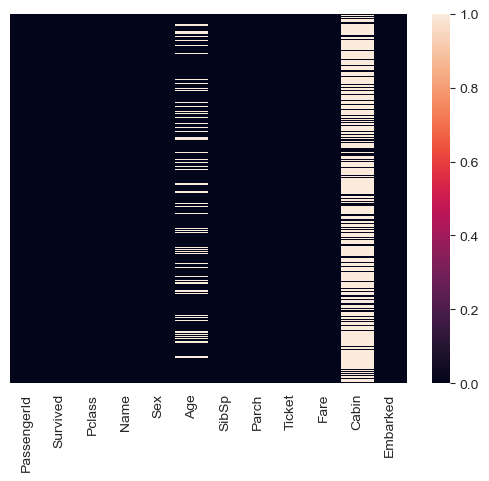

In [181]:
sns.heatmap(train.isnull(),yticklabels=False )

<Axes: xlabel='Survived', ylabel='count'>

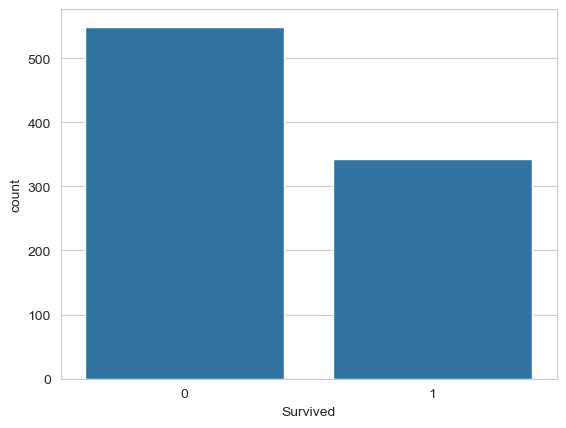

In [182]:
sns.countplot(train,x='Survived')

<Axes: xlabel='Survived', ylabel='count'>

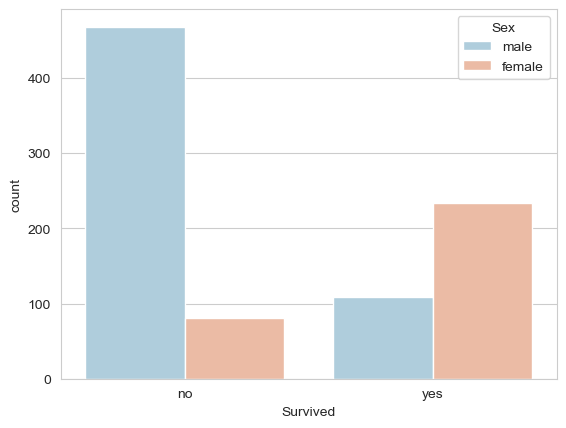

In [183]:
sns.countplot(x=train['Survived'].map({
    0:'no', 1:'yes'
}), hue='Sex',data=train, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

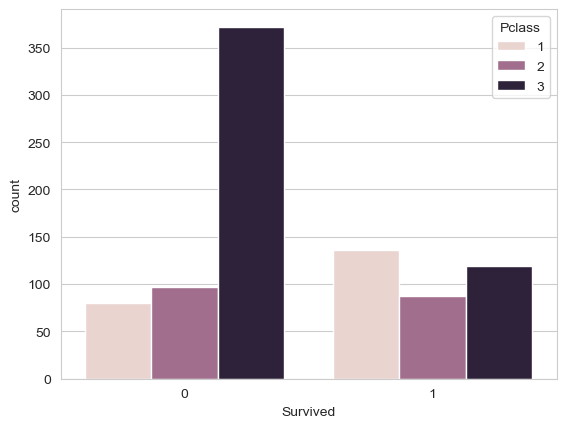

In [184]:
sns.countplot(train,x='Survived', hue='Pclass')

<Axes: xlabel='Age', ylabel='Survived'>

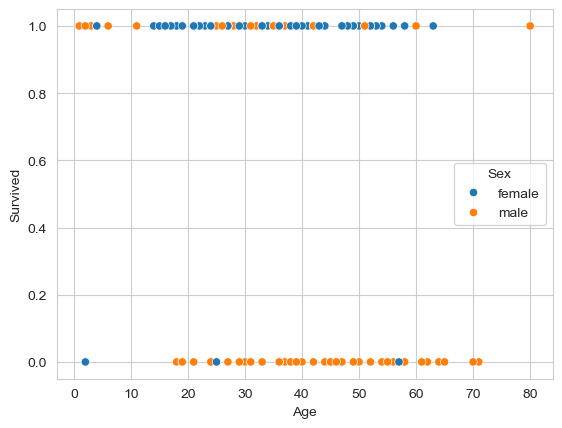

In [185]:
sns.scatterplot(data=train.dropna(), x='Age', y='Survived', hue='Sex')

C:\Users\PiyushChunara\AppData\Local\Temp\ipykernel_6884\1463015962.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'])


<Axes: xlabel='Age', ylabel='Density'>

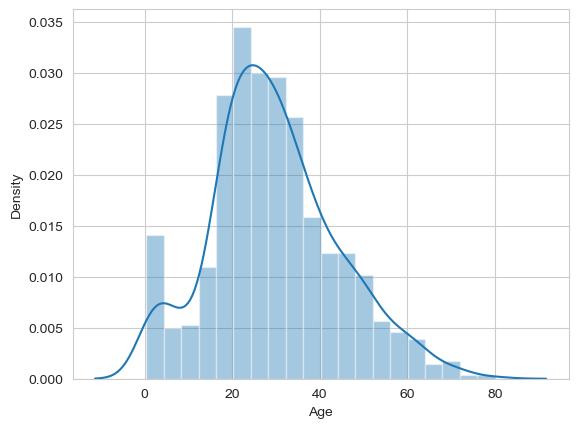

In [186]:
sns.distplot(train['Age'])

<Axes: xlabel='SibSp', ylabel='count'>

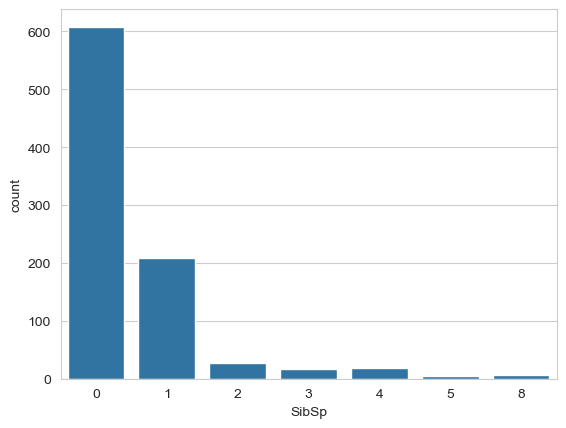

In [187]:
sns.countplot(train, x='SibSp')

C:\Users\PiyushChunara\AppData\Local\Temp\ipykernel_6884\891094164.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

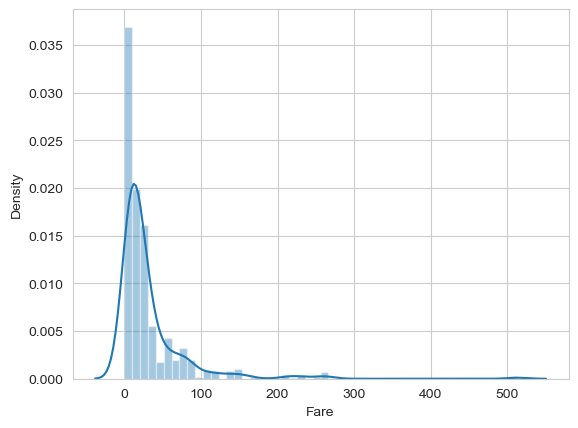

In [188]:
sns.distplot(train['Fare'])

## clean Data

In [189]:
train.Age.isna().sum()

np.int64(177)

<Axes: ylabel='Age'>

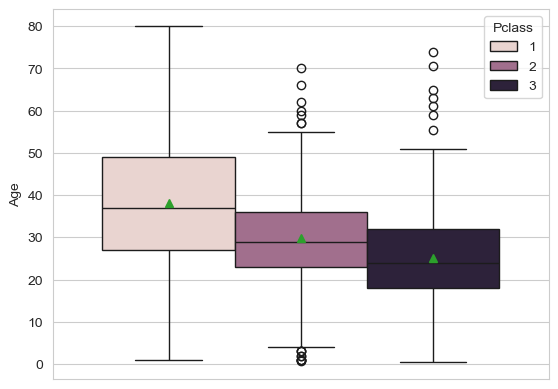

In [190]:
sns.boxplot(train, y='Age', hue='Pclass', showmeans=True)

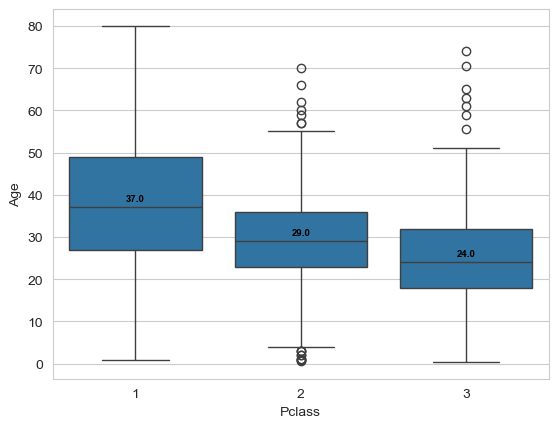

In [191]:
sns.set_style("whitegrid")
box_plot = sns.boxplot(x='Pclass',y="Age",data=train)

medians = train.groupby(['Pclass'])['Age'].median()
vertical_offset = train['Age'].median() * 0.05 # offset from median for display

for xtick, pclass in enumerate(sorted(train['Pclass'].unique())):
    box_plot.text(
        xtick,
        medians[pclass] + vertical_offset,
        round(medians[pclass], 1),
        horizontalalignment='center',
        size='x-small',
        color='black',
        weight='semibold'
    )

plt.show()

In [192]:
def impute_age(cols):
    age = cols[0]
    Pclass = cols[1]
    # print(age, Pclass)
    if pd.isnull(age):
        if Pclass == 1:
            return 37
        elif Pclass ==2:
            return 29
        else:
            return 24
    return age

In [193]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age,axis=1 )


C:\Users\PiyushChunara\AppData\Local\Temp\ipykernel_6884\1909273228.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = cols[0]
C:\Users\PiyushChunara\AppData\Local\Temp\ipykernel_6884\1909273228.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [194]:
train.Age.isna().sum()

np.int64(0)

In [195]:
train.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
763,764,1,1,"Carter, Mrs. William Ernest (Lucile Polk)",female,36.0,1,2,113760,120.00,B96 B98,S
434,435,0,1,"Silvey, Mr. William Baird",male,50.0,1,0,13507,55.90,E44,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.05,NaN,S
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.50,B77,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.90,NaN,S


<Axes: ylabel='Age'>

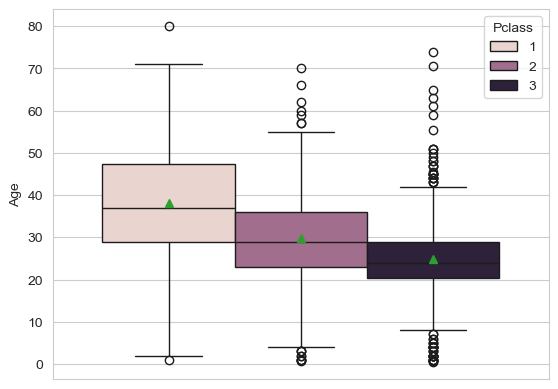

In [166]:
sns.boxplot(train, y='Age', hue='Pclass', showmeans=True)

In [196]:
train.drop(columns='Cabin', inplace=True)

In [197]:
train.dropna(inplace=True)

In [198]:
train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

<Axes: >

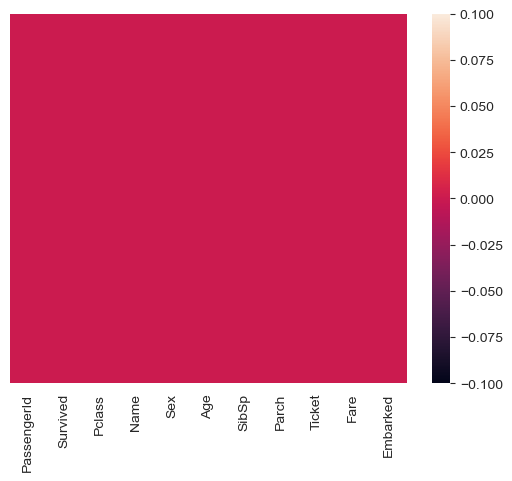

In [199]:
sns.heatmap(train.isnull(),yticklabels=False )

In [200]:
train['Sex'] = train['Sex'].apply(lambda x: 1 if x == 'male' else 0)

In [201]:
embark = pd.get_dummies(train['Embarked'], drop_first=True)

In [202]:
embark

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


In [203]:
train = pd.concat([train,embark], axis=1)

In [204]:
train.drop(columns=['Embarked','Name','Ticket',], inplace=True)

In [205]:
# train.head()

In [206]:
train.drop(columns='PassengerId', inplace=True)

In [207]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Q,S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [208]:
X = train.drop(columns='Survived')
y = train['Survived']

In [209]:
from sklearn.model_selection import train_test_split

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

In [212]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [213]:
lr.fit(X_train, y_train)

C:\Users\PiyushChunara\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [214]:
pred = lr.predict(X_test)

In [217]:
df = pd.DataFrame({'Pred': pred, 'Actual': y_test})


<Axes: xlabel='Pred', ylabel='count'>

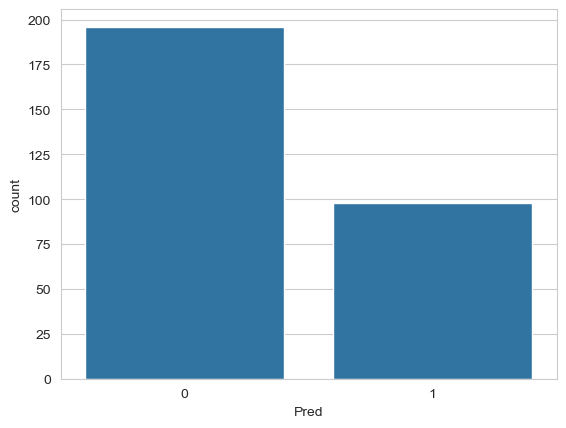

In [227]:
sns.countplot(df,x=df['Pred'], )

In [231]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [232]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       174
           1       0.83      0.68      0.74       120

    accuracy                           0.81       294
   macro avg       0.81      0.79      0.80       294
weighted avg       0.81      0.81      0.81       294



In [233]:
confusion_matrix(y_test, pred)

array([[157,  17],
       [ 39,  81]])